In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from PIL import Image

import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision

In [2]:
imdb = torch.load('data\charsdb.pth')
imdb['sets'].shape

C:\Users\mymai\AppData\Local\Temp\ipykernel_29212\1109421441.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  imdb = torch.load('data\charsdb.pth')


torch.Size([29094])

torch.Size([770, 1, 32, 32])


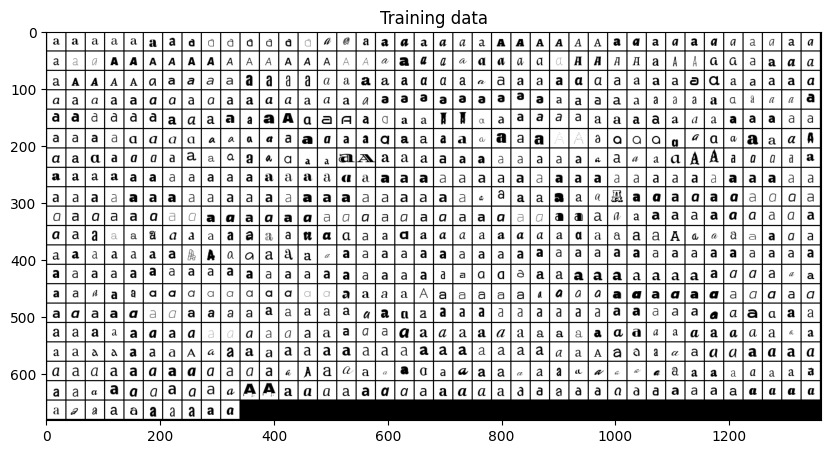

In [3]:
########################################################################################################################
## Making a grid plot of the training data for 'a'
########################################################################################################################

plt.figure(1,figsize=(10,10))
plt.clf()
plt.title('Training data')
sel=(imdb['sets']==0) & (imdb['labels']==0)

images_sel=(imdb['images'][sel,:,:,:])
print(images_sel.size())

tensor_grid=torchvision.utils.make_grid(images_sel,nrow=40)
image_grid=tensor_grid.permute(1,2,0)
plt.imshow(image_grid)

tensor([0.5628], grad_fn=<ViewBackward0>)


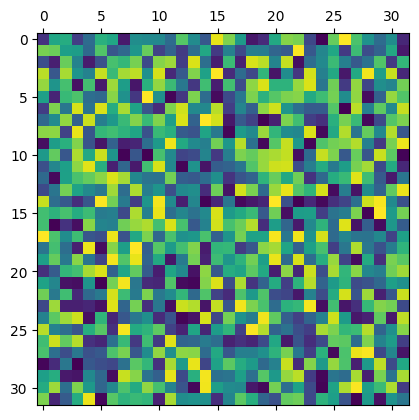

<Figure size 500x500 with 0 Axes>

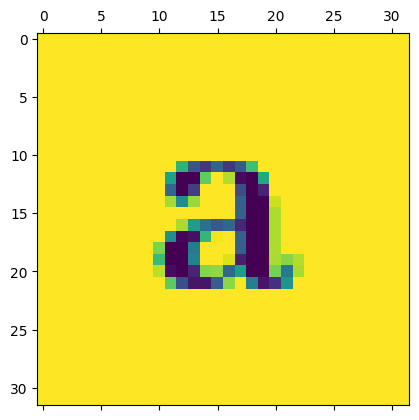

In [4]:
########################################################################################################################
## Build a fully connected layer with 32x32 input and 1 output
########################################################################################################################

# Initialize the layer and extract the weights
model=nn.Linear(32*32,1)
weight=model.weight

## Display the weights as an image
weight=weight.reshape(32,32).detach().numpy()
plt.figure(2,figsize=(5,5))
plt.matshow(weight);

# Transform a sample image into a flat array 32*32x1 
sample_image=images_sel[0,:,:,:].squeeze()

plt.figure(2,figsize=(5,5))
plt.matshow(sample_image);

image_flatten=torch.flatten(sample_image)

# Apply the fully connected layer to the image
prediction=model(image_flatten)
print(prediction)

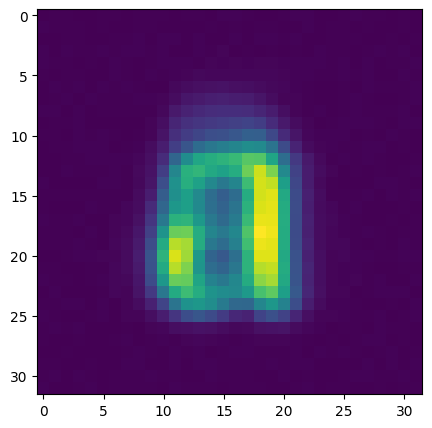

In [5]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Prepare all images to be processed by the fully connected neuron
image_view=torch.flatten(images_sel,1,3)
label=0
#print(image_view.size())

# Compute the output of all 'a'
prediction=model(image_view);

# Compute the difference between prediction and true label 
loss=(prediction-label).sum()

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Show the updated weights
weight=model.weight.reshape(32,32).detach().numpy()

plt.figure(2,figsize=(5,5))
plt.imshow(weight);

torch.Size([5, 1, 28, 28])

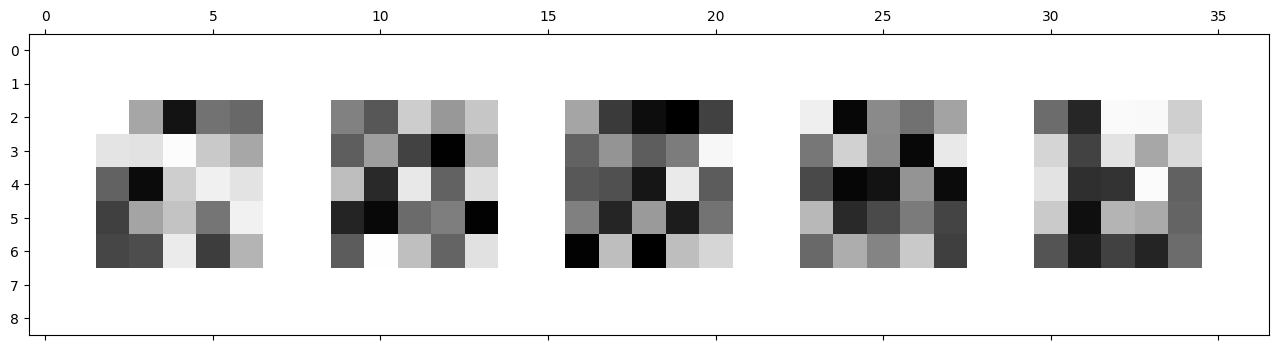

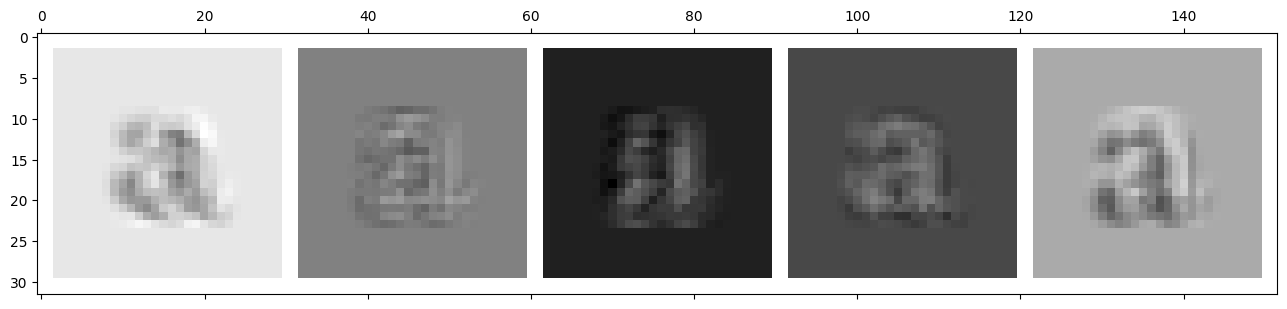

In [6]:
########################################################################################################################
## Build a convolutional layer with 5 filters, 5x5
########################################################################################################################

# Initialize the layer
model=nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)

#Extract and plot the weights
weight=model.weight.detach()

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
image_filtered=model(sample_image)
image_filtered=image_filtered.permute(1,0,2,3)

# plot resulting feature maps
tensor_grid=torchvision.utils.make_grid(image_filtered,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid)

image_filtered.size()

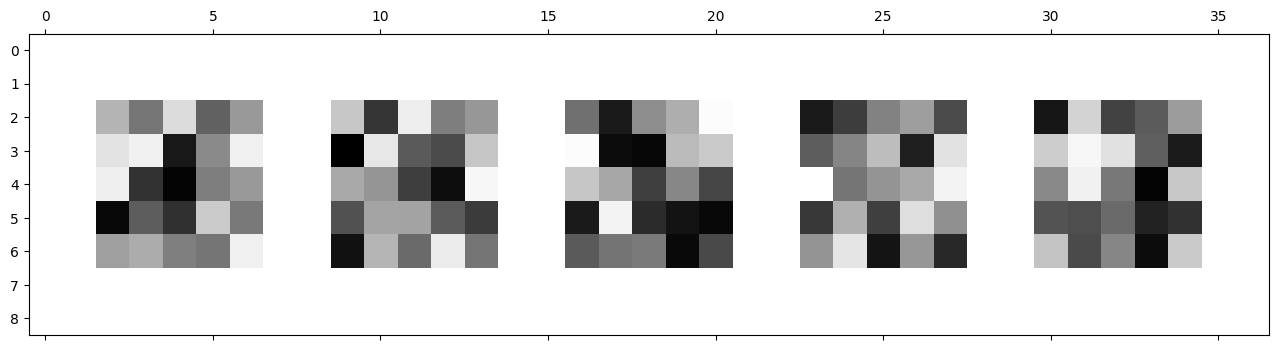

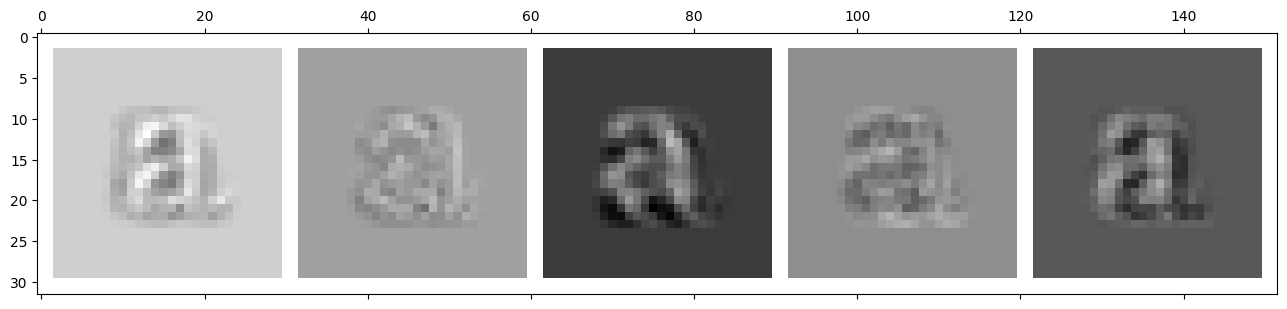

In [7]:
########################################################################################################################
## Build a small convolutional network
########################################################################################################################

# Define the model
class CNN_model(nn.Module):
    def __init__(self):
        super(CNN_model, self).__init__()
        
        self.layer_1 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)
        self.layer_2 = nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, groups=5)
        self.layer_3=nn.Flatten(1,3)
        self.layer_4=nn.Linear(24*24*5,26)
        
    def forward(self,x):
        x1 = self.layer_1(x)
        x = nn.ReLU()(x1)
        x2 = self.layer_2(x)
        x = nn.ReLU()(x2)
        x = self.layer_3(x)
        x = nn.ReLU()(x)
        x = self.layer_4(x)
        
        return x, x1, x2

# Initialize the model
model=CNN_model()

# Display the filters of layer 1
weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH and apply the network to the image
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
x,x1,x2=model(sample_image)

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

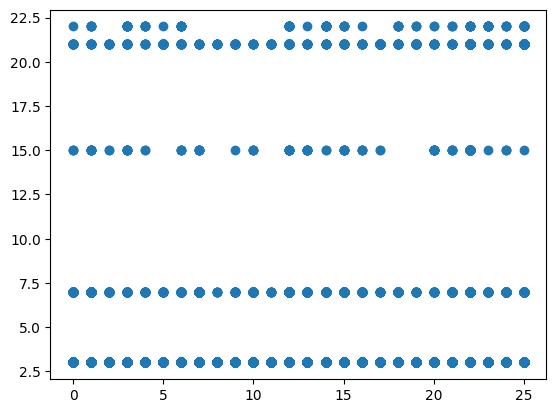

In [8]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

loss_fun=nn.CrossEntropyLoss()

labels=imdb['labels']
inputs=imdb['images']

# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Compute the difference between prediction and true label 
#loss=((preds-labels)**2).sum()
loss=loss_fun(prediction,labels)

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Visializing the predictions
plt.plot(labels,preds.detach().numpy(),'o')

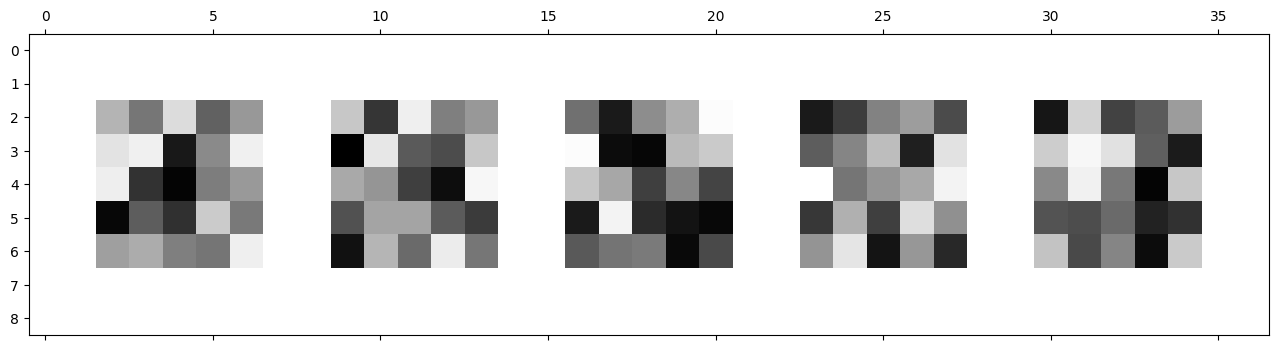

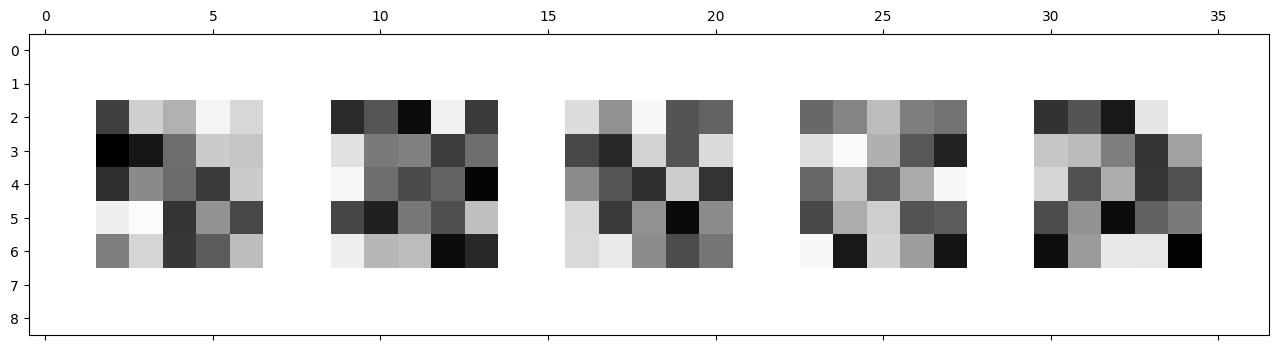

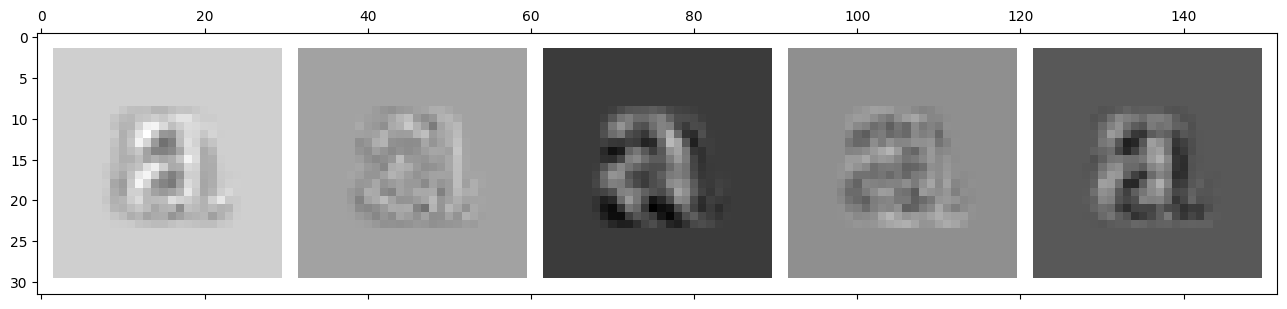

In [9]:
########################################################################################################################
## Visualizing updated weights
########################################################################################################################

weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

weight=model.layer_2.weight
tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

x,x1,x2=model(images_sel[0,:,:,:].unsqueeze(0))

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

In [10]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

# Splitting data into training and validation
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    imdb['images'],imdb['labels'],
    test_size=0.2, 
    random_state=42,
)

#Defining the Dataset 
class Char_Dataset(Dataset):
    def __init__(self,data,target,train:bool = True, transforms=None):
        self.data=data
        self.target=target
        self.train=train
        self.transforms=transforms
        
    def __getitem__(self,index):
        
        x=self.data[index,]
        
        if(self.train):
            if(self.transforms):
                x=self.transforms(x)
                
        
        if(self.train):
            # During training, for each image the Dataset returns
            #  - an image x
            #  - the true class y:  
            y=self.target[index,]
            return x,y
        else:
            # During testing, only the image is returned
            return x
        
    def __len__(self):
        return len(self.target)
    
# Initializion datasets and dataloaders
batch_size = 500

train_dataset=Char_Dataset(
    data=Xtrain,
    target=Ytrain,
    train=True,
    transforms=None
)

valid_dataset=Char_Dataset(
    data=Xvalid,
    target=Yvalid,
    train=True,
    transforms=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

In [11]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################
datasets={'train':train_dataset,'valid':valid_dataset}
dataloaders={'train':train_loader,'valid':valid_loader}

optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

# if GPU is available, use it, otherwise use CPU
#device = torch.device("cuda")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

for epoch in range(num_epochs):

    running_loss = 0.0
    running_corrects = 0.0
        
    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels=labels.to(device)

            # Zero out the grads
            optimizer.zero_grad()

            # Forward
            # Track history in train mode
            with torch.set_grad_enabled(phase == 'train'):
                model=model.to(device)
                outputs, x1, x2 = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels.type(torch.LongTensor).to(device))

                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                
                # Statistics
                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss/len(datasets[phase])
        epoch_acc = running_corrects.double()/len(datasets[phase])
        print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

train Loss: 2.7262 Acc: 0.2766
valid Loss: 12.3840 Acc: 1.7127
train Loss: 0.9435 Acc: 0.7534
valid Loss: 4.4998 Acc: 3.8333
train Loss: 0.6250 Acc: 0.8388
valid Loss: 3.2288 Acc: 4.1583
train Loss: 0.5525 Acc: 0.8555
valid Loss: 2.9168 Acc: 4.2351
train Loss: 0.5003 Acc: 0.8654
valid Loss: 2.6348 Acc: 4.3033
train Loss: 0.4567 Acc: 0.8751
valid Loss: 2.4255 Acc: 4.3588
train Loss: 0.4311 Acc: 0.8801
valid Loss: 2.3036 Acc: 4.3846
train Loss: 0.3818 Acc: 0.8959
valid Loss: 2.0990 Acc: 4.4506
train Loss: 0.9623 Acc: 0.7399
valid Loss: 4.5949 Acc: 3.7749
train Loss: 0.4667 Acc: 0.8679
valid Loss: 2.4901 Acc: 4.3220


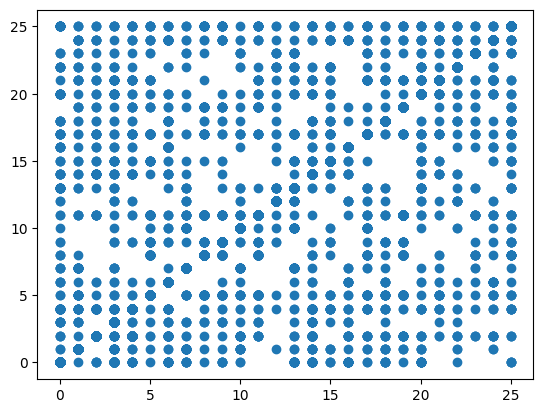

In [12]:
labels=imdb['labels']
inputs=imdb['images']

model=model.to(torch.device("cpu"))
# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Visualizing the predictions
plt.plot(labels,preds.detach().numpy(),'o')